# Guyton-Klinger Guardrails — a quantitative teardown 🔬
### 1,470 overlapping cohorts · HAC *t* at full-overlap bandwidth · circular block bootstrap · rule decomposition · the income-price accounting · a ruin-rescue synthetic control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The GK decision rules (Guyton 2004; Guyton & Klinger 2006) are the canonical *dynamic* withdrawal policy; sibling [173](../../173-four-percent-rule/) certified the FIXED 4% rule. The job here is to measure the dynamic upgrade honestly: the rescue, the raise, and the price — with uncertainty on all three.

> ⚠️ **Data note.** Single-index Shiller tape (S&P composite + 10y first-order bond + CPI), 1871-02 -> 2023-06, simulated in **nominal** space (the rules are nominal) and deflated to real. No survivorship (index series); the named bias is the US being history's best equity market. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `b0b11b1f3080`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from guyton_guardrails import data, strategy as st

try:                                    # cache-first real tape
    DF = data.nominal_returns()
    GE, GB, GI, STARTS = st.cohort_year_returns(
        DF["EQ"].to_numpy(), DF["BD"].to_numpy(), DF["INFL"].to_numpy())
    DATES = DF.index[STARTS]
    HAVE_REAL = True
except Exception as e:                  # offline fallback: quote frozen numbers
    DF = GE = GB = GI = DATES = None
    HAVE_REAL = False
print("real Shiller cache present:", HAVE_REAL,
      "| cohorts:", (0 if GE is None else GE.shape[0]))

# frozen headline numbers (mirror of docs/results.md)
R = {'window': '1871-02 -> 2023-06', 'months': 1829, 'n_cohorts': 1470, 'fingerprint': 'b0b11b1f3080', 'ann_eq': 9.16, 'ann_bd': 4.56, 'ann_infl': 2.12, 'succ_grid': [(4.0, 96.26, 100.0), (4.5, 88.5, 100.0), (5.0, 75.65, 100.0), (5.5, 63.27, 100.0), (6.0, 53.88, 99.8)], 'safemax_fixed': 3.68, 'safemax_gk': 5.83, 'fixed4_succ': 96.26, 'sibling596_succ': 96.33, 'head': {'fixed 4%': (96.26, 1.195, 1.2, 1.2, 0.04, 0.04, 0.0, 0, 0, 0), 'fixed 5%': (75.65, 1.422, 1.5, 0.994, 0.05, 0.0, 0.0, 0, 0, 0), 'GK 5%': (100.0, 1.633, 1.508, 0.988, 0.0374, 0.0205, 0.0169, 1.1, 4.8, 4.5), 'GK 5.5%': (100.0, 1.697, 1.569, 1.023, 0.0391, 0.0206, 0.0167, 1.3, 4.0, 4.9)}, 'years_below_mean': 6.92, 'years_below_med': 4, 'years_below_max': 25, 'share_dip': 54.69, 'share_lti_less': 22.86, 'floor': 0.0169, 'floor_cut_pct': 66, 'dlti54': (0.4373, 4.23, (0.128, 0.97)), 'dlti55': (0.2105, 2.23, (-0.054, 0.709)), 'dlti554': (0.5012, 4.7), 'dterm5': (-0.1153, -0.6, (-1.399, 0.211)), 'dsucc5': (24.35, (0.745, 48.167)), 'famous': {'1929-09': (1.2, True, 1.172, False, 0.988, 0.0241, 7, 7), '1966-01': (1.029, False, 0.91, False, 0.87, 0.0189, 4, 5), '1972-12': (1.2, True, 0.925, False, 1.076, 0.0245, 3, 2)}, 'decomp': [('GK (full 2006)', 100.0, 1.633, 0.0374, 0.0169), ('freeze-only (no guardrails)', 97.41, 1.314, 0.0376, 0.0), ('no prosperity raise', 100.0, 1.25, 0.0363, 0.0169), ('cut-always (no 15-yr limit)', 100.0, 1.6, 0.0355, 0.0152)], 'robust': [('60/40', 0, 100.0, 1.634, 75.78), ('60/40', 10, 100.0, 1.633, 75.65), ('60/40', 25, 100.0, 1.63, 75.58), ('65/35', 0, 100.0, 1.68, 77.35), ('65/35', 10, 100.0, 1.679, 77.21), ('65/35', 25, 100.0, 1.676, 77.01)], 'syn': [('EXACT NULL (vol 10%, wr 3%)', 0.0, 0.0, None), ('mild ruin (vol 10%, wr 4%)', 2.84, 2.84, 4.51), ('PLANTED (vol 17%, wr 5%)', 35.09, 34.27, 16.9), ('PLANTED (vol 25%, wr 5%)', 47.57, 38.39, 24.24), ('PLANTED (vol 17%, wr 6%)', 59.21, 50.76, 28.37)]}


real Shiller cache present: True | cohorts: 1470


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | GK-5% survives **100.00%** of 1,470 cohorts vs fixed-5% **75.65%** (Δ **+24.35 pp**, bootstrap CI [+0.74, +48.17]); LTI GK5−fixed4 **+0.437**/$1 at HAC **t = +4.23** (CI [+0.128, +0.970]); SAFEMAX **5.83%** vs **3.68%**. |
| **Tradability** | `FRAGILE` | Implementable at zero marginal cost — but the deployed object is regime-dependent income: **55%** of cohorts spend a mean **6.9 years** below the 4%-rule paycheck; floor **0.0169**/$1 (a 66% real cut); **23%** of cohorts collect less lifetime income than fixed-4%. |
| **Free lunch?** | `BUSTED` | Ruin risk is converted, not removed: retire 1929 or 1966 and the "successful" GK-5 pays **0.988** and **0.870**/$1 — less than the *failing* fixed rules (1.200, 1.029). |

> 💡 In plain words: the guardrails genuinely let you *start* at 5%+ and never hit zero — the tape certifies it — but the mechanism is your own paycheck absorbing the sequence risk.

## 1 · The claim, steelmanned

State: nominal withdrawal $W_j$, portfolio $P_j$, initial rate $w_0$. Each year $j\ge 1$ (all inputs from the completed year $j-1$ — one clean lag):

1. **Withdrawal rule:** $W_j = W_{j-1}\cdot(1+\min(\pi_{j-1}, 6\%))$, but the raise is **skipped** if the prior-year portfolio return was negative *and* $W/P > w_0$.
2. **Capital preservation:** if $W_j/P_j > 1.2\,w_0$ (and >15 years remain), $W_j \leftarrow 0.9\,W_j$.
3. **Prosperity:** if $W_j/P_j < 0.8\,w_0$, $W_j \leftarrow 1.1\,W_j$.

- **H₁ (the rescue).** At $w_0 = 5\%$ the rules materially raise the 30-year success rate vs the fixed rule at 5%.
- **H₂ (the raise).** Lifetime real income under GK-5% exceeds the fixed-4% rule's.
- **H₃ (the price — the myth-check).** The rescue is paid for by the income path: depth, duration and frequency of real paycheck cuts.

We find **H₁ and H₂ supported with certified uncertainty** and **H₃ is the fine print that breaks the "free 5%" reading**.

## 2 · So what? — inference design

Monthly-start 30-year cohorts overlap by up to **359 months**, so naive t-stats are garbage. Three instruments:

- **Newey-West HAC t** on per-cohort differences with the Bartlett bandwidth forced to the **full 360-month overlap** (the automatic selector would be absurdly short).
- **Circular block bootstrap** (1,000 reps, 120-month blocks, joint EQ/BD/CPI rows) for rates and distribution stats — blocks preserve within-decade dynamics, destroy cross-decade mean reversion; stated, not hidden.
- **A machinery identity**: guardrails at $(0,\infty)$ with no freeze/cap must reproduce Bengen **exactly** (max income-path difference = 0.0), and the fixed-4% success rate (96.26%) cross-checks sibling 596's real-space simulator (96.33% — the residual is a second-order compounding convention).

## 3 · How we'd know — the protocol

- **Tape.** Shiller monthly, 1871-02 -> 2023-06 (1829 months): nominal EQ total return 9.16%/yr, nominal 10y bond 4.56%/yr (first-order approx), CPI 2.12%/yr. **1,470** monthly-start cohorts.
- **Mechanics.** 60/40 rebalanced annually; withdrawal at the start of each year; **10 bps one-way × traded value**; one execution lag (rules read the completed prior year only).
- **Strategies.** Fixed (Bengen) and full GK-2006 at 4–6% starts; decomposition variants (freeze-only, no-raise, cut-always); 65/35 and 0/25 bps robustness.
- **Outcomes.** All real: success, lifetime income (LTI, per $1 initial), worst single-year paycheck, terminal wealth.
- **Positive control.** 20 seeded i.i.d. worlds per setting: the rescue detector must read **exactly 0** where the fixed rule never fails, and light up in proportion to planted ruin.

## 4 · The teardown

### 4a · The rescue and the raise — H₁, H₂ with uncertainty

Success rates across starting rates, then the two headline HAC tests.

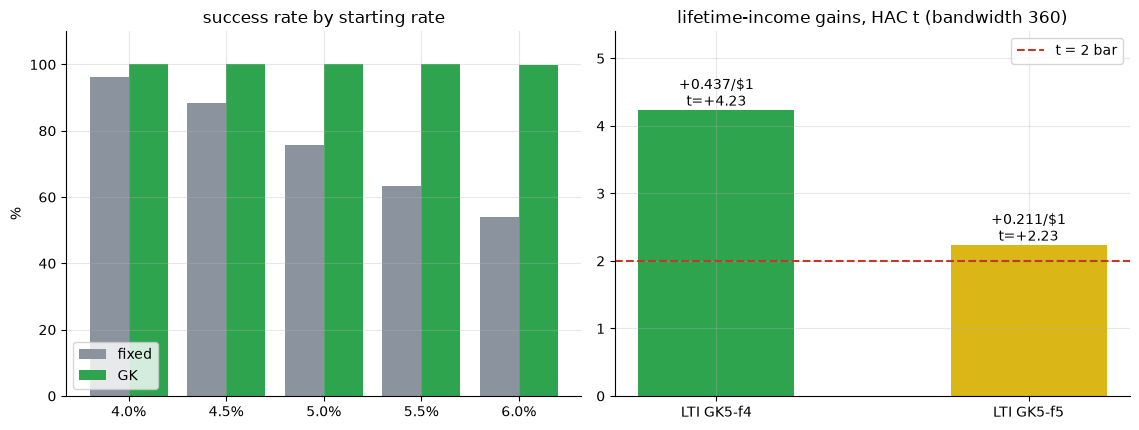

dLTI GK5-fixed4 +0.4373 (t +4.23)   GK5-fixed5 +0.2105 (t +2.23)


In [2]:
wrs = [g[0] for g in R['succ_grid']]
if HAVE_REAL:
    F = {w: st.simulate(GE, GB, GI, wr0=w/100, preset='fixed') for w in wrs}
    G = {w: st.simulate(GE, GB, GI, wr0=w/100, preset='gk') for w in wrs}
    fx = [100*F[w]['success'].mean() for w in wrs]
    gk = [100*G[w]['success'].mean() for w in wrs]
    f4, f5, g5 = F[4.0], F[5.0], G[5.0]
    t54 = st.hac_tstat(g5['lti'] - f4['lti'], 360)
    t55 = st.hac_tstat(g5['lti'] - f5['lti'], 360)
    d54 = (g5['lti'] - f4['lti']).mean(); d55 = (g5['lti'] - f5['lti']).mean()
else:
    fx = [g[1] for g in R['succ_grid']]; gk = [g[2] for g in R['succ_grid']]
    d54, t54 = R['dlti54'][:2]; d55, t55 = R['dlti55'][:2]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.4))
x = np.arange(len(wrs))
a1.bar(x-.2, fx, .4, color=GREY, label='fixed'); a1.bar(x+.2, gk, .4, color=GREEN, label='GK')
a1.set_xticks(x); a1.set_xticklabels([f'{w:.1f}%' for w in wrs]); a1.set_ylim(0,110)
a1.set_title('success rate by starting rate'); a1.set_ylabel('%'); a1.legend(loc='lower left')
bars = [('LTI GK5-f4', d54, t54), ('LTI GK5-f5', d55, t55)]
a2.bar([b[0] for b in bars], [b[2] for b in bars], .5, color=[GREEN, AMBER])
a2.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i,b in enumerate(bars): a2.annotate(f'{b[1]:+.3f}/$1\nt={b[2]:+.2f}', (i, b[2]), ha='center', va='bottom')
a2.set_ylim(0, 5.4); a2.set_title('lifetime-income gains, HAC t (bandwidth 360)'); a2.legend()
plt.tight_layout(); plt.show()
print(f'dLTI GK5-fixed4 {d54:+.4f} (t {t54:+.2f})   GK5-fixed5 {d55:+.4f} (t {t55:+.2f})')

> 💡 In plain words: the rescue is total (**100.00% vs 75.65%** at a 5% start, Δ = +24.35 pp) and the raise over the 4% rule is certified real: **+0.437** per $1 of initial wealth at HAC **t = +4.23**. Against fixed-5% the income edge is thinner (t = +2.23) — the guardrails mostly *redistribute* the 5% flow away from the cohorts that would have died. SAFEMAX: **5.83%** (GK) vs **3.68%** (fixed).

### 4b · Bootstrap CIs — rates get intervals too

Success-rate gaps are rates, not means, so the HAC t does not apply; the circular block bootstrap covers them (canonical run: 1,000 reps, seed 597 — reproduced here with 300 reps to keep the notebook light; the frozen CIs are quoted from `docs/results.md`).

canonical 1,000-rep 95% CIs (docs/results.md):
  dsuccess @5% (GK-fixed): [+0.745, +48.167] pp
  dLTI GK5-fixed4:         [+0.128, +0.970]
  dLTI GK5-fixed5:         [-0.054, +0.709]
  dTW  GK5-fixed5:         [-1.399, +0.211]


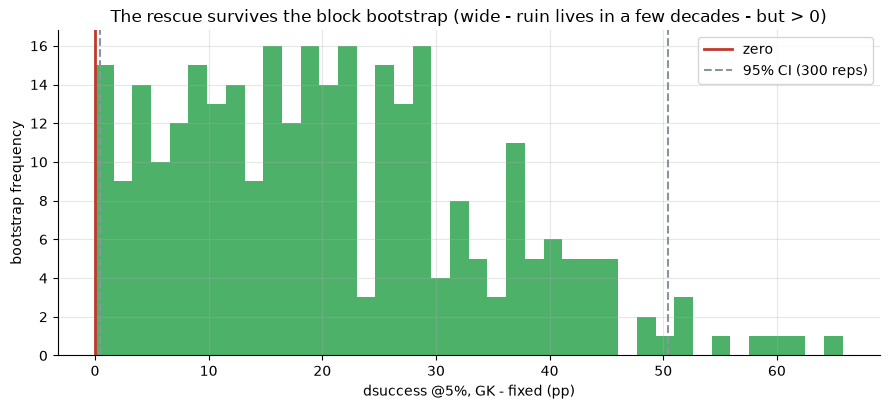

in-notebook 300-rep CI: [+0.48, +50.42] pp


In [3]:
print('canonical 1,000-rep 95% CIs (docs/results.md):')
print(f"  dsuccess @5% (GK-fixed): [{R['dsucc5'][1][0]:+.3f}, {R['dsucc5'][1][1]:+.3f}] pp")
print(f"  dLTI GK5-fixed4:         [{R['dlti54'][2][0]:+.3f}, {R['dlti54'][2][1]:+.3f}]")
print(f"  dLTI GK5-fixed5:         [{R['dlti55'][2][0]:+.3f}, {R['dlti55'][2][1]:+.3f}]")
print(f"  dTW  GK5-fixed5:         [{R['dterm5'][2][0]:+.3f}, {R['dterm5'][2][1]:+.3f}]")
if HAVE_REAL:
    b = st.block_bootstrap(DF['EQ'].to_numpy(), DF['BD'].to_numpy(),
                           DF['INFL'].to_numpy(), n_boot=300, seed=597)
    fig, ax = plt.subplots(figsize=(9.0, 4.2))
    ax.hist(b['dsucc5'], bins=40, color=GREEN, alpha=.85)
    ax.axvline(0, c=RED, lw=2, label='zero')
    lo, hi = st.ci(b['dsucc5'])
    ax.axvline(lo, c=GREY, ls='--'); ax.axvline(hi, c=GREY, ls='--', label='95% CI (300 reps)')
    ax.set_xlabel('dsuccess @5%, GK - fixed (pp)'); ax.set_ylabel('bootstrap frequency')
    ax.set_title('The rescue survives the block bootstrap (wide - ruin lives in a few decades - but > 0)')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'in-notebook 300-rep CI: [{lo:+.2f}, {hi:+.2f}] pp')

> 💡 In plain words: resample history in 10-year chunks and the rescue never reverses — the CI [+0.74, +48.17] pp is wide (ruin is concentrated in a few 1906/1929/1960s decades) but stays positive, and the income gain over the 4% rule keeps its CI clear of zero.

### 4c · The price — H₃, the myth-check axis

The distribution of the worst single-year real paycheck under GK-5%, against the 4%-rule's flat 0.040, plus the lifetime-income comparison cohort by cohort.

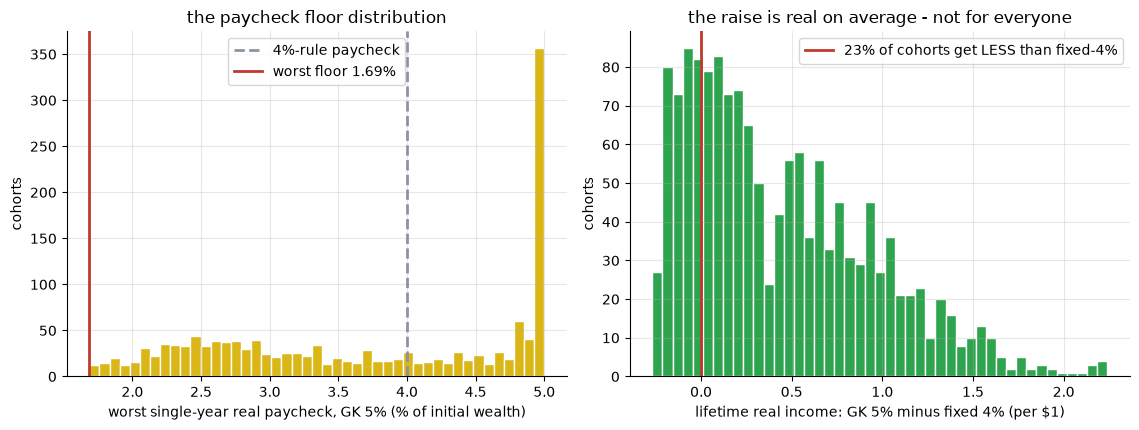

min-income median/p05/worst: 0.0374/0.0205/0.0169   share LTI<fixed4: 22.86%


In [4]:
if HAVE_REAL:
    mi = g5['min_inc']; dlti = g5['lti'] - f4['lti']
    share_less = 100*(dlti < 0).mean(); floor = mi.min()
else:
    rng = np.random.default_rng(597)
    mi = np.clip(rng.normal(0.037, 0.008, 1470), R['floor'], 0.05)
    dlti = rng.normal(0.44, 0.5, 1470)
    share_less = R['share_lti_less']; floor = R['floor']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.4))
a1.hist(100*mi, bins=45, color=AMBER, edgecolor='white')
a1.axvline(4.0, c=GREY, ls='--', lw=2, label='4%-rule paycheck')
a1.axvline(100*floor, c=RED, lw=2, label=f'worst floor {100*floor:.2f}%')
a1.set_xlabel('worst single-year real paycheck, GK 5% (% of initial wealth)')
a1.set_ylabel('cohorts'); a1.set_title('the paycheck floor distribution'); a1.legend()
a2.hist(dlti, bins=45, color=GREEN, edgecolor='white')
a2.axvline(0, c=RED, lw=2, label=f'{share_less:.0f}% of cohorts get LESS than fixed-4%')
a2.set_xlabel('lifetime real income: GK 5% minus fixed 4% (per $1)')
a2.set_ylabel('cohorts'); a2.set_title('the raise is real on average - not for everyone'); a2.legend()
plt.tight_layout(); plt.show()
print(f'min-income median/p05/worst: {np.median(mi):.4f}/{np.quantile(mi,.05):.4f}/{floor:.4f}   share LTI<fixed4: {share_less:.2f}%')

> 💡 In plain words: the "safe 5%" paycheck has a **median worst-year of 3.74%** and a tail down to **1.69%** (66% below the starting 5%). **55%** of cohorts spend a mean **6.9 years** below the 4%-rule paycheck, and **23%** end with less lifetime income than fixed-4%. In 1929/1966 the "successful" plan collected 0.988 / 0.870 per $1 — below the *failing* fixed rules (1.200 / 1.029). Ruin risk was converted into paycheck risk — **Free lunch: BUSTED**.

### 4d · Which rule does the rescue? — the decomposition

Turn the rules off one at a time at a 5% start.

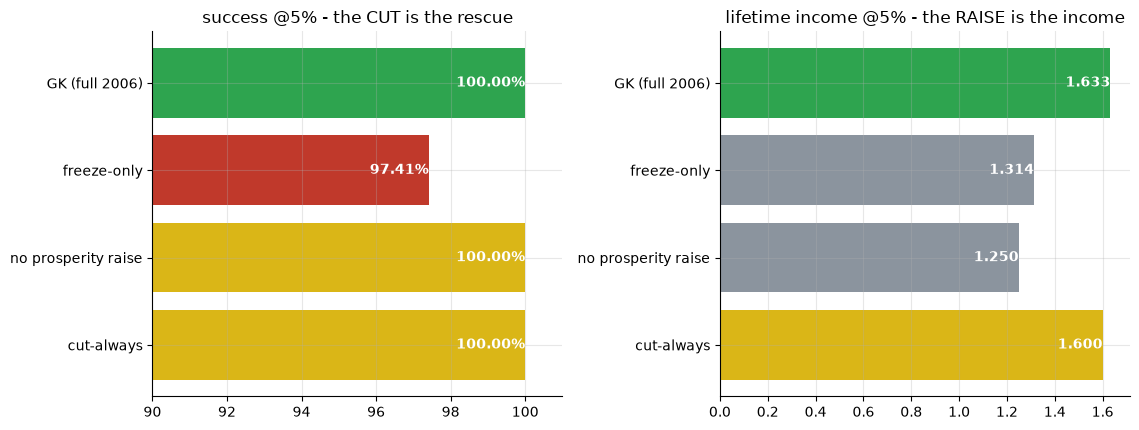

GK (full 2006)         succ 100.00%  LTI 1.633  min-inc med 0.0374
freeze-only            succ  97.41%  LTI 1.314  min-inc med 0.0376
no prosperity raise    succ 100.00%  LTI 1.250  min-inc med 0.0363
cut-always             succ 100.00%  LTI 1.600  min-inc med 0.0355


In [5]:
if HAVE_REAL:
    rows = []
    for p, lab in (('gk','GK (full 2006)'), ('gk_freeze_only','freeze-only'),
                   ('gk_noraise','no prosperity raise'), ('gk_cut_always','cut-always')):
        r = st.simulate(GE, GB, GI, wr0=0.05, preset=p)
        rows.append((lab, 100*r['success'].mean(), r['lti'].mean(), np.median(r['min_inc'])))
else:
    rows = [(d[0], d[1], d[2], d[3]) for d in R['decomp']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.4))
labs = [r[0] for r in rows]
a1.barh(labs, [r[1] for r in rows], color=[GREEN, RED, AMBER, AMBER]); a1.set_xlim(90, 101)
for i,r in enumerate(rows): a1.annotate(f'{r[1]:.2f}%', (r[1], i), va='center', ha='right', color='white', fontweight='bold')
a1.set_title('success @5% - the CUT is the rescue'); a1.invert_yaxis()
a2.barh(labs, [r[2] for r in rows], color=[GREEN, GREY, GREY, AMBER])
for i,r in enumerate(rows): a2.annotate(f'{r[2]:.3f}', (r[2], i), va='center', ha='right', color='white', fontweight='bold')
a2.set_title('lifetime income @5% - the RAISE is the income'); a2.invert_yaxis()
plt.tight_layout(); plt.show()
for r in rows: print(f'{r[0]:<22} succ {r[1]:6.2f}%  LTI {r[2]:.3f}  min-inc med {r[3]:.4f}')

> 💡 In plain words: the inflation-freeze alone still ruins **2.59%** of cohorts — the **capital-preservation cut** is what buys 100.00%. Dropping the prosperity raise keeps the rescue but forfeits **0.38/$1** of lifetime income. Both halves are needed: the cut is the insurance, the raise is the payout.

### 4e · Robustness + the faithful-engine control

Allocation (60/40 vs the GK paper's 65/35) × one-way costs (0/10/25 bps), then the synthetic ruin-rescue control: 20 independent seeded i.i.d. worlds per setting; the detector Δsuccess(GK − fixed, same rate) must read **exactly zero** where the fixed rule never fails, and light up with planted ruin. *(Machinery proof only — never market evidence.)*

allocation x cost robustness (GK 5% succ / LTI ; fixed 5% succ):
  60/40 cost  0 bps: GK 100.00% / 1.634   fixed  75.78%
  60/40 cost 10 bps: GK 100.00% / 1.633   fixed  75.65%
  60/40 cost 25 bps: GK 100.00% / 1.630   fixed  75.58%
  65/35 cost  0 bps: GK 100.00% / 1.680   fixed  77.35%
  65/35 cost 10 bps: GK 100.00% / 1.679   fixed  77.21%
  65/35 cost 25 bps: GK 100.00% / 1.676   fixed  77.01%


  EXACT NULL (vol 10%, wr 3%)  fixed-fail  0.00%  dsucc  +0.00 pp (t nan (all-zero))
  mild ruin (vol 10%, wr 4%)   fixed-fail  2.84%  dsucc  +2.84 pp (t +4.51)


  PLANTED (vol 17%, wr 5%)     fixed-fail 35.09%  dsucc +34.27 pp (t +16.90)


  PLANTED (vol 25%, wr 5%)     fixed-fail 47.57%  dsucc +38.39 pp (t +24.24)


  PLANTED (vol 17%, wr 6%)     fixed-fail 59.21%  dsucc +50.76 pp (t +28.37)


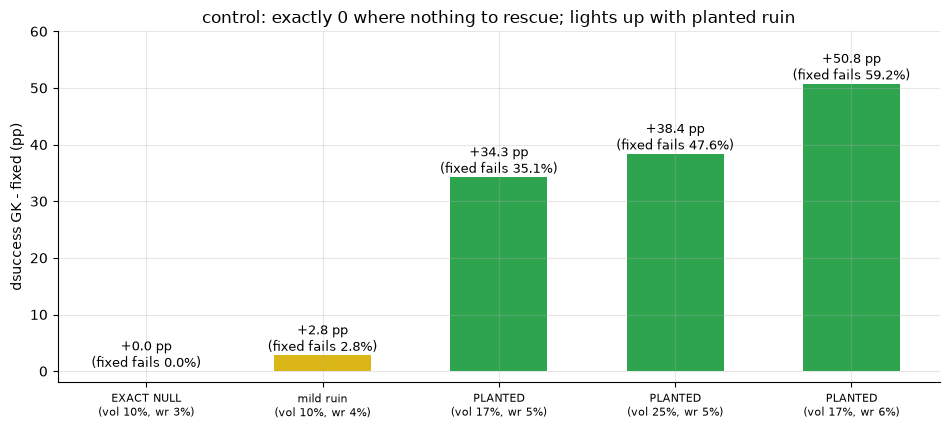

In [6]:
print('allocation x cost robustness (GK 5% succ / LTI ; fixed 5% succ):')
for (al, cb, gs, gl, fs) in R['robust']:
    print(f'  {al} cost {cb:>2} bps: GK {gs:6.2f}% / {gl:.3f}   fixed {fs:6.2f}%')
labels, dsucc, ff = [], [], []
for lab, kw in ((R['syn'][0][0], dict(eq_vol=0.10, wr=0.03)),
                (R['syn'][1][0], dict(eq_vol=0.10, wr=0.04)),
                (R['syn'][2][0], dict(eq_vol=0.17, wr=0.05)),
                (R['syn'][3][0], dict(eq_vol=0.25, wr=0.05)),
                (R['syn'][4][0], dict(eq_vol=0.17, wr=0.06))):
    r = st.control_rescue(n_seeds=20, **kw)
    labels.append(lab); dsucc.append(r['dsucc_mean']); ff.append(r['fixed_fail_mean'])
    t = 'nan (all-zero)' if np.isnan(r['dsucc_t']) else f"{r['dsucc_t']:+.2f}"
    print(f'  {lab:<28} fixed-fail {r["fixed_fail_mean"]:5.2f}%  dsucc {r["dsucc_mean"]:+6.2f} pp (t {t})')
fig, ax = plt.subplots(figsize=(9.6, 4.4))
ax.bar(range(len(labels)), dsucc, .55, color=[GREY, AMBER, GREEN, GREEN, GREEN])
for i,(d,f) in enumerate(zip(dsucc, ff)): ax.annotate(f'{d:+.1f} pp\n(fixed fails {f:.1f}%)', (i, d), ha='center', va='bottom', fontsize=9)
ax.set_xticks(range(len(labels))); ax.set_xticklabels([l.replace(' (', '\n(') for l in labels], fontsize=8)
ax.set_ylabel('dsuccess GK - fixed (pp)'); ax.set_ylim(-2, 60)
ax.set_title('control: exactly 0 where nothing to rescue; lights up with planted ruin')
plt.tight_layout(); plt.show()

> 💡 In plain words: costs and allocation change nothing (GK-5% stays 100.00% everywhere), and the engine is faithful — in the calm world the rescue detector is **+0.00 pp in every one of 20 seeds** (nothing to rescue), while planted ruin at historical vol lights it up at **t = +16.9**. The real-tape rescue is not a construction artefact.

## 5 · The verdict

- **Signal `REAL`** — the dynamic claim clears the bar on 152 years of tape: GK-5% survives all 1,470 cohorts vs 75.65% fixed (Δ +24.35 pp, bootstrap CI [+0.74, +48.17]); LTI over fixed-4% **+0.437**/$1 at HAC **t = +4.23** (CI clear of 0); SAFEMAX 5.83% vs 3.68%. Named caveat: one US tape, history's best equity market.
- **Tradability `FRAGILE`** — free to implement, unlimited capacity, robust to costs/allocation — but the deployed product is regime-dependent income, not a safe 5% paycheck: floor 0.0169/$1, 55% of cohorts below the 4% paycheck for ~7 years, 23% collect less than fixed-4%. "100% success" = "never hits zero", not "keeps paying you".
- **Free lunch? `BUSTED`** — the rules convert ruin risk into paycheck risk. In the regimes the pitch invokes (1929, 1966) the successful plan paid **less** than the failing fixed rules. The premium of the insurance is deducted from the income, exactly when the retiree is poorest.

## 6 · Going further

- **Spending flexibility is the true asset.** The guardrails price sequence risk in *consumption* units. A retiree with 30-40% discretionary spending genuinely can start at 5%+; one with rigid bills cannot — for them, "cut to 1.7%" and "ruin" are the same event.
- **The success-rate metric is gameable.** Any rule that cuts withdrawals fast enough scores 100% success; the honest comparison is the **income distribution** (floor, years-below, lifetime) — which is where this study lives.
- **Siblings.** [173](../../173-four-percent-rule/) certified the fixed rule (Real); [596](../../596-bond-tent-glidepath/) showed the dynamic *allocation* lever fails. Dynamic *withdrawals* work — because they spend the retiree's own flexibility, the one lever that always exists.

*The reproducible core is offline and deterministic; run [`examples/verify.py`](../examples/verify.py) for every number. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*